In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('aps_failure_training_set.csv', na_values='na')

In [4]:
df

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,neg,153002,NaN,6.640000e+02,186.0,0.0,0.0,0.0,0.0,0.0,...,998500.0,566884.0,1290398.0,1218244.0,1019768.0,717762.0,898642.0,28588.0,0.0,0.0
59996,neg,2286,NaN,2.130707e+09,224.0,0.0,0.0,0.0,0.0,0.0,...,10578.0,6760.0,21126.0,68424.0,136.0,0.0,0.0,0.0,0.0,0.0
59997,neg,112,0.0,2.130706e+09,18.0,0.0,0.0,0.0,0.0,0.0,...,792.0,386.0,452.0,144.0,146.0,2622.0,0.0,0.0,0.0,0.0
59998,neg,80292,NaN,2.130706e+09,494.0,0.0,0.0,0.0,0.0,0.0,...,699352.0,222654.0,347378.0,225724.0,194440.0,165070.0,802280.0,388422.0,0.0,0.0


In [5]:
df.shape

(60000, 171)

In [6]:
import seaborn as sns
from statistics import mean
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix

from sklearn import metrics
from sklearn.model_selection import train_test_split,RepeatedStratifiedKFold,cross_val_score
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,KNNImputer
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
%matplotlib inline

In [7]:
df['class'].value_counts()

class
neg    59000
pos     1000
Name: count, dtype: int64

In [8]:
# Define Categorical and numerical features
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('we have {} numerical features : {}'.format(len(numerical_features),numerical_features))
print('\nwe have {} categorical features : {}'.format(len(categorical_features),categorical_features))

we have 170 numerical features : ['aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000', 'ck_000'

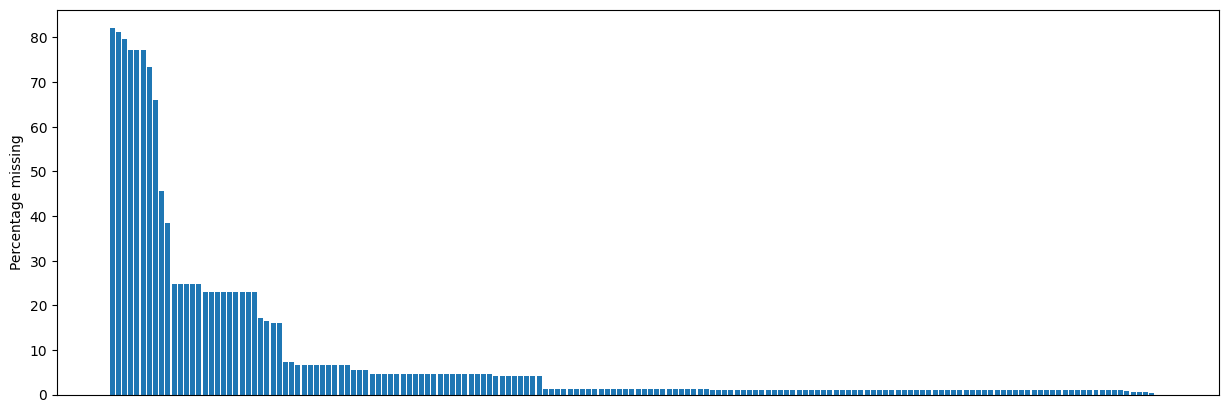

In [9]:
# Plotting missing values count for each columns
fig, ax = plt.subplots(figsize=(15,5))

missing = df.isna().sum().div(df.shape[0]).mul(100).to_frame().sort_values(by=0, ascending=False)

ax.bar(missing.index, missing.values.T[0])
plt.xticks([])
plt.ylabel("Percentage missing")
plt.show()

In [10]:
# Dropping the columns which has more than 70% missing data
dropcols = missing[missing[0]>70]
dropcols

,0
br_000,82.106667
bq_000,81.203333
bp_000,79.566667
bo_000,77.221667
ab_000,77.215000
cr_000,77.215000
bn_000,73.348333


In [11]:
df.drop(list(dropcols.index),axis=1, inplace=True)

In [12]:
df.shape

(60000, 164)

In [13]:
missing_values_count = df.isnull().sum()
total_cells = np.prod(df.shape)

total_missing = missing_values_count.sum()
print(f"Percentage of total missing cells in the data {(total_missing/total_cells) * 100}%")

Percentage of total missing cells in the data 5.29765243902439%


Positive: 1000, Negative: 59000


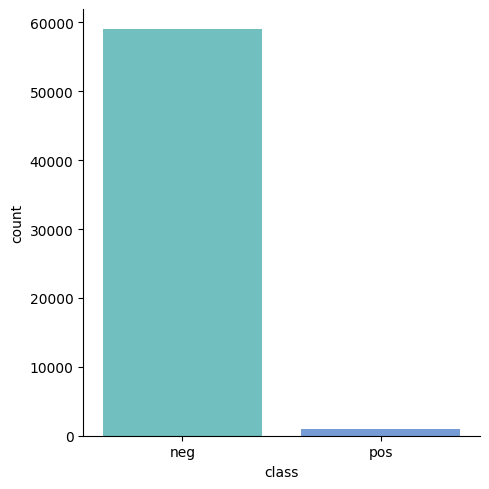

In [14]:
pos = df[df['class'] == 'pos'].shape[0]
neg = df[df['class'] == 'neg'].shape[0]
print("Positive: " + str(pos) + ", Negative: " + str(neg))
sns.catplot(data=df, x="class", kind="count", palette="winter_r", alpha=.6)
plt.show()

In [15]:
# Creating a function for model training and evaluation
def evaluate_clf(true, predicted):
    acc = accuracy_score(true,predicted)
    f1 = f1_score(true,predicted)
    precision = precision_score(true,predicted)
    recall = recall_score(true,predicted)
    roc_auc = roc_auc_score(true,predicted)
    return acc,f1,precision,recall,roc_auc

In [16]:
def total_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = 10*fp + 500*fn
    return cost

In [17]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    cost_list=[]
    models_list = []
    accuracy_list = []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        model_train_accuracy, model_train_f1,model_train_precision,\
        model_train_recall,model_train_rocauc_score=evaluate_clf(y_train ,y_train_pred)
        train_cost = total_cost(y_train, y_train_pred)


        # Test set performance
        model_test_accuracy,model_test_f1,model_test_precision,\
        model_test_recall,model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)
        test_cost = total_cost(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))
        print(f'- COST: {train_cost}.')

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        print(f'- COST: {test_cost}.')
        cost_list.append(test_cost)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, cost_list)), columns=['Model Name', 'Cost']).sort_values(by=["Cost"])
        
    return report

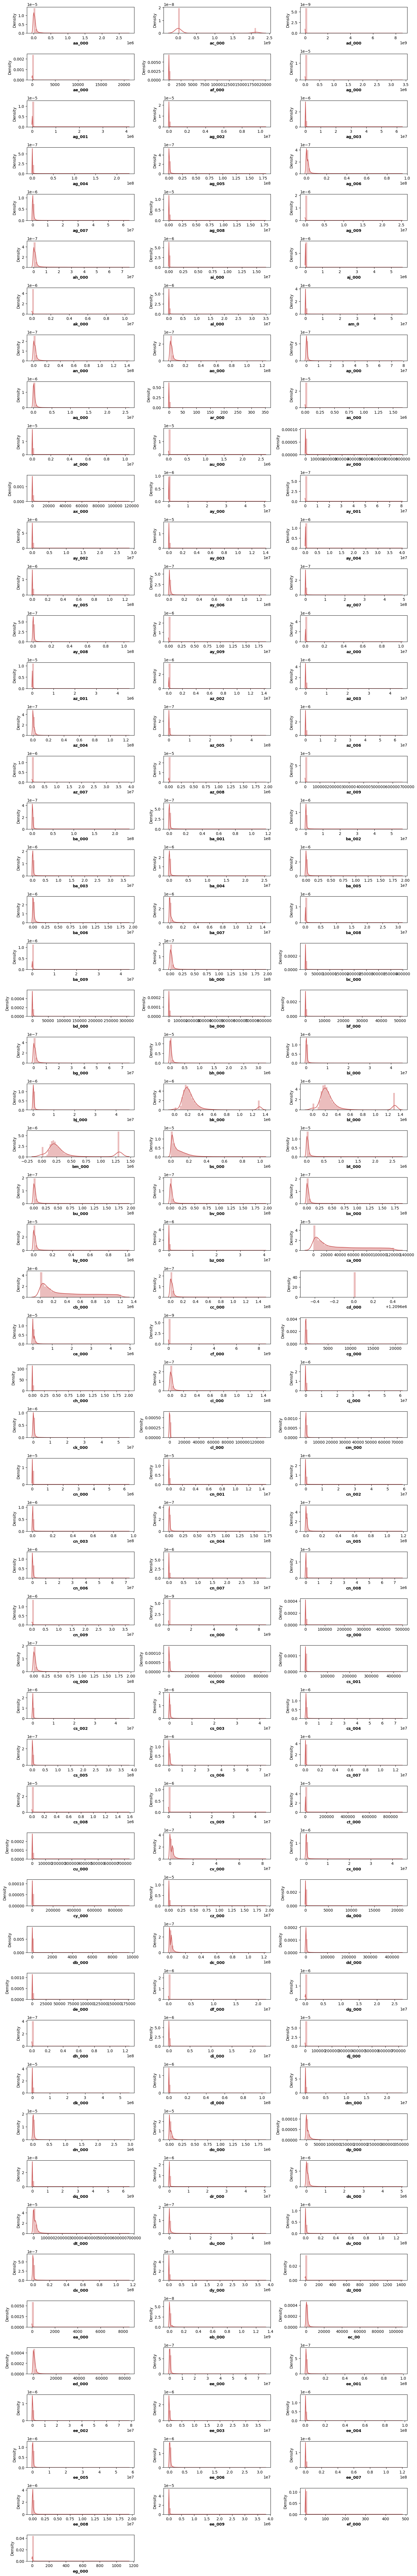

In [18]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']

plt.figure(figsize=(15,100))
for i, col in enumerate(numerical_features):
    plt.subplot(60, 3, i+1)
    sns.distplot(x=df[col], color = 'indianred')
    plt.xlabel(col, weight='bold')
    plt.tight_layout()

In [19]:
# Splitting x and y for all
X = df.drop('class', axis=1)
y = df['class']

In [20]:
y = y.replace({'pos': 1, 'neg': 0})

In [21]:
y

0        0
1        0
2        0
3        0
4        0
        ..
59995    0
59996    0
59997    0
59998    0
59999    0
Name: class, Length: 60000, dtype: int64

Experiment1 KNN imputer for Null values

Why robust Scaler and not standard Scaler?

1) Scaling the data using Robust Scaler
2) Since most of the data is not normally distributed we can't use Standard Scaler

Why Robust Scaler and not minmax?

1) Because most of the features have outliers. So MinMax will scale the data according to max value which is an outlier
2) This Scaler removes median and scales the data according to the quaartile range


In [22]:
from sklearn.preprocessing import RobustScaler
robustscaler = RobustScaler()
X1 = robustscaler.fit_transform(X)

**Why KNN Imputer**?
- KNNImputer by scikit-learn is a widely used method to impute missing values. It is widely being observed as a replacement for traditional imputation techniques.
- KNNImputer helps to impute missing values present in the observations by finding the nearest neighbors with the Euclidean distance matrix.
- Here we Iterates through different K values and get accuracy and choose best K values.

In [23]:
results=[]
# define imputer
imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean')
strategies = [str(i) for i in [1,3,5,7,9]]
for s in strategies:
    pipeline = Pipeline(steps=[('i', KNNImputer(n_neighbors=int(s))), ('m', LogisticRegression())])
    scores = cross_val_score(pipeline, X1, y, scoring='accuracy', cv=2, n_jobs=-1)
    results.append(scores)
    print('n_neighbors= %s || accuracy (%.4f)' % (s , mean(scores)))

n_neighbors= 1 || accuracy (0.7678)
n_neighbors= 3 || accuracy (0.7467)
n_neighbors= 5 || accuracy (0.7431)
n_neighbors= 7 || accuracy (0.7562)
n_neighbors= 9 || accuracy (0.7397)


**We can observe n_neighbors=1 able to produce highest accuracy**

In [24]:
# Pipeline for KNN imputer
num_features = X.select_dtypes(exclude="object").columns

# Fit the KNN imputer with selected K-value
knn_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=1)),
    ('RobustScaler', RobustScaler())
])

In [25]:
X_knn =knn_pipeline.fit_transform(X)

## Handling Imbalanced data

 **SMOTE+TOMEK** is one of such a hybrid technique that aims to clean overlapping data points for each of the classes distributed in sample space.
 
 - This method combines the SMOTE ability to generate synthetic data for minority class and Tomek Links ability to remove the data that are identified as Tomek links from the majority class
 
 - To add new data of minority class
 1. Choose random data from the minority class.
 2. Calculate the distance between the random data and its k nearest neighbors.
 3. Multiply the difference with a random number between 0 and 1, then add the result to the minority class as a synthetic sample.
 4. Repeat step number 2–3 until the desired proportion of minority class is met.
 
 - To remove the tomek links of the majority class
 1. Choose random data from the majority class.
 2. If the random data’s nearest neighbor is the data from the minority class (i.e. create the Tomek Link), then remove the Tomek Link.
 
 - This is method instead of adding duplicate data it synthesises the new data based on the already avalialble classes. Hence we choose this as our imputer method for this problem.

In [26]:
from imblearn.combine import SMOTETomek

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority',n_jobs=-1)
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_knn, y)

In [27]:
# Dictionary which contains models for experiment
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [28]:
report_knn = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9949
- F1 score: 0.9948
- Precision: 0.9921
- Recall: 0.9975
- Roc Auc Score: 0.9949
- COST: 15420.


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9911
- F1 score: 0.9910
- Precision: 0.9885
- Recall: 0.9935
- Roc Auc Score: 0.9912
- COST: 38840.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9850
- F1 score: 0.9851
- Precision: 0.9812
- Recall: 0.9890
- Roc Auc Score: 0.9850
- COST: 269450.
----------------------------------
Model performance for Test set
- Accuracy: 0.9838
- F1 score: 0.9837
- Precision: 0.9801
- Recall: 0.9873
- Roc Auc

In [29]:
report_knn

,Model Name,Cost
5,XGBClassifier,5960
6,CatBoosting Classifier,11190
0,Random Forest,15420
1,Decision Tree,38840
4,K-Neighbors Classifier,64930
2,Gradient Boosting,76330
7,AdaBoost Classifier,183610
3,Logistic Regression,619410


**Insights**
- For the Experiment 1: Knn imputer has XGBoost classifier as the best Model
- Proceeding with further experiments 

### Experiment: 2 = Simple Imputer with Strategy Median 

- SimpleImputer is a class in the `sklearn.impute` module that can be used to replace missing values in a dataset, using a variety of input strategies.
- Here we use SimpleImputer can also be used to impute multiple columns at once by passing in a list of column names. SimpleImputer will then replace missing values in all of the specified columns.

In [30]:
num_features = X.select_dtypes(exclude="object").columns

# Fit the Simple imputer with strategy median
median_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('RobustScaler', RobustScaler())
])

In [31]:
# Fit X with median_pipeline
X_median = median_pipeline.fit_transform(X)

In [32]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority')
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_median, y)

In [33]:
# Training the models
report_median = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9955
- F1 score: 0.9955
- Precision: 0.9927
- Recall: 0.9983
- Roc Auc Score: 0.9956
- COST: 10850.


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9906
- F1 score: 0.9905
- Precision: 0.9879
- Recall: 0.9931
- Roc Auc Score: 0.9906
- COST: 41410.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9837
- F1 score: 0.9838
- Precision: 0.9803
- Recall: 0.9873
- Roc Auc Score: 0.9837
- COST: 309370.
----------------------------------
Model performance for Test set
- Accuracy: 0.9829
- F1 score: 0.9827
- Precision: 0.9779
- Recall: 0.9876
- Roc Auc

In [34]:
report_median

,Model Name,Cost
5,XGBClassifier,5000
6,CatBoosting Classifier,5610
0,Random Forest,10850
1,Decision Tree,41410
4,K-Neighbors Classifier,72120
2,Gradient Boosting,74590
7,AdaBoost Classifier,179900
3,Logistic Regression,620230


**Insights**
- For the Experiment 2: Simple imputer with median strategy has XGBClassifier as the best Model
- Proceeding with further experiments 

### Experiment: 3 = Simple Imputer with Strategy Constant 

- Another strategy which can be used is replacing missing values with a fixed (constant) value.
- To do this, specify “constant” for strategy and specify the fill value using the fill_value parameter

In [35]:
# Create a pipeline with simple imputer with strategy constant and fill value 0
constant_pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('RobustScaler', RobustScaler())
])

In [36]:
X_const =constant_pipeline.fit_transform(X)

In [37]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority', n_jobs=-1 )
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_const, y)

In [38]:
# training the models
report_const = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9953
- F1 score: 0.9953
- Precision: 0.9922
- Recall: 0.9983
- Roc Auc Score: 0.9953
- COST: 10910.


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9893
- F1 score: 0.9892
- Precision: 0.9850
- Recall: 0.9934
- Roc Auc Score: 0.9893
- COST: 40260.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9832
- F1 score: 0.9833
- Precision: 0.9796
- Recall: 0.9870
- Roc Auc Score: 0.9832
- COST: 315710.
----------------------------------
Model performance for Test set
- Accuracy: 0.9809
- F1 score: 0.9808
- Precision: 0.9775
- Recall: 0.9841
- Roc Auc

## Report for Simple Imputer with Constant strategy

In [39]:
report_const

,Model Name,Cost
5,XGBClassifier,5050
0,Random Forest,10910
6,CatBoosting Classifier,11490
1,Decision Tree,40260
4,K-Neighbors Classifier,64020
2,Gradient Boosting,95140
3,Logistic Regression,167910
7,AdaBoost Classifier,172300


**Insights**
- For the Experiment 3: Simple imputer with constant strategy has XGBoost classifier as the best Model
- Proceeding with further experiments 

## Experiment: 4 = Simple Imputer with Strategy Mean 

- Another strategy which can be used is replacing missing values with mean
- Here we replace the missing values with the mean of the column

In [40]:
# Create a pipeline with Simple imputer with strategy mean
mean_pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='mean')),
    ('RobustScaler', RobustScaler())
])

In [41]:
X_mean = mean_pipeline.fit_transform(X)

In [42]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority' , n_jobs=-1)
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_mean, y)

In [43]:
# Training all models
report_mean = evaluate_models(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9941
- F1 score: 0.9940
- Precision: 0.9906
- Recall: 0.9974
- Roc Auc Score: 0.9942
- COST: 16090.


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
- COST: 0.
----------------------------------
Model performance for Test set
- Accuracy: 0.9906
- F1 score: 0.9905
- Precision: 0.9869
- Recall: 0.9941
- Roc Auc Score: 0.9907
- COST: 35530.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9859
- F1 score: 0.9860
- Precision: 0.9826
- Recall: 0.9893
- Roc Auc Score: 0.9858
- COST: 260770.
----------------------------------
Model performance for Test set
- Accuracy: 0.9837
- F1 score: 0.9834
- Precision: 0.9794
- Recall: 0.9876
- Roc Auc

### Report for Simple imputer with strategy mean

In [44]:
report_mean

,Model Name,Cost
5,XGBClassifier,5020
6,CatBoosting Classifier,13700
0,Random Forest,16090
1,Decision Tree,35530
4,K-Neighbors Classifier,55630
2,Gradient Boosting,74410
7,AdaBoost Classifier,182920
3,Logistic Regression,587980


### Experiment: 5 = Principle component analysis with imputing median

- Principal component analysis is a technique for feature extraction — so it combines our input variables in a specific way, then we can drop the “least important” variables while still retaining the most valuable parts of all of the variables! 
- As the dataset has 164 columns we can try PCA and check our metrics Cost

In [45]:
from sklearn.decomposition import PCA

In [46]:
pca_pipeline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('RobustScaler', RobustScaler())
])

In [47]:
X_pca = pca_pipeline.fit_transform(X)

In [48]:
#Applying PCA
from sklearn.decomposition import PCA
var_ratio={}
for n in range(2,150):
    pc=PCA(n_components=n)
    df_pca=pc.fit(X_pca)
    var_ratio[n]=sum(df_pca.explained_variance_ratio_)

<Axes: >

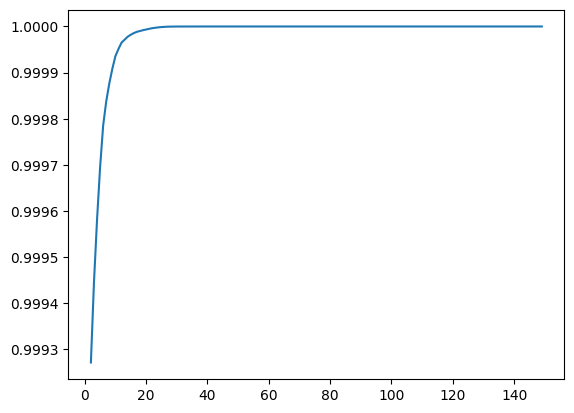

In [49]:
# plotting variance ratio
pd.Series(var_ratio).plot()

<Figure size 500x500 with 0 Axes>

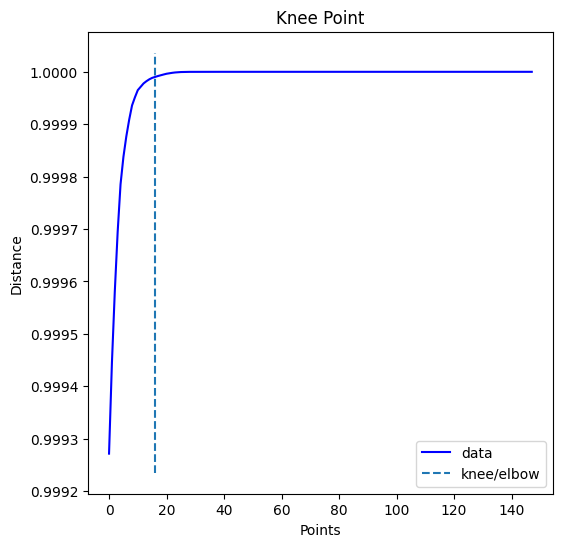

Knee Locator k = 18


In [50]:
from kneed import KneeLocator

i = np.arange(len(var_ratio))
variance_ratio= list(var_ratio.values())
components=  list(var_ratio.keys())
knee = KneeLocator(i, variance_ratio, S=1, curve='concave', interp_method='polynomial')

fig = plt.figure(figsize=(5, 5))
knee.plot_knee()
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()
k= components[knee.knee]
print('Knee Locator k =', k)

In [51]:
# Reducing the dimensions of the data 
pca_final=PCA(n_components=18,random_state=42).fit(X_res)

reduced=pca_final.fit_transform(X_pca)

In [52]:
# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority', n_jobs=-1)
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(reduced, y)

In [53]:
# Training all models
report_pca = evaluate_models(X_res,y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 0.9992
- F1 score: 0.9992
- Precision: 0.9991
- Recall: 0.9994
- Roc Auc Score: 0.9992
- COST: 15410.
----------------------------------
Model performance for Test set
- Accuracy: 0.9870
- F1 score: 0.9869
- Precision: 0.9816
- Recall: 0.9922
- Roc Auc Score: 0.9870
- COST: 47160.


Decision Tree
Model performance for Training set
- Accuracy: 0.9992
- F1 score: 0.9992
- Precision: 0.9991
- Recall: 0.9994
- Roc Auc Score: 0.9992
- COST: 15410.
----------------------------------
Model performance for Test set
- Accuracy: 0.9794
- F1 score: 0.9793
- Precision: 0.9722
- Recall: 0.9865
- Roc Auc Score: 0.9795
- COST: 81770.


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9387
- F1 score: 0.9386
- Precision: 0.9420
- Recall: 0.9353
- Roc Auc Score: 0.9387
- COST: 1552130.
----------------------------------
Model performance for Test set
- Accuracy: 0.9380
- F1 score: 0.9370
- Precision: 0.9397
- Recall: 0.9343


In [54]:
report_pca

,Model Name,Cost
0,Random Forest,47160
1,Decision Tree,81770
5,XGBClassifier,92870
6,CatBoosting Classifier,93650
4,K-Neighbors Classifier,134120
2,Gradient Boosting,387950
7,AdaBoost Classifier,531650
3,Logistic Regression,1011300


## Final Model

In [71]:
from prettytable import PrettyTable

pt=PrettyTable()
pt.field_names=["Model","Imputation_method","Total_cost"]
pt.add_row(["XGBClassifier","Median","5000"])
pt.add_row(["XGBClassifier","Simple Imputer-Constant","5050"])
pt.add_row(["XGBClassifier","Knn-Imputer","5960"])
pt.add_row(["XGBClassifier","Simple Imputer-Mean","5020"])
pt.add_row(["Random Forest","PCA","47160"])
print(pt)

+---------------+-------------------------+------------+
|     Model     |    Imputation_method    | Total_cost |
+---------------+-------------------------+------------+
| XGBClassifier |          Median         |    5000    |
| XGBClassifier | Simple Imputer-Constant |    5050    |
| XGBClassifier |       Knn-Imputer       |    5960    |
| XGBClassifier |   Simple Imputer-Mean   |    5020    |
| Random Forest |           PCA           |   47160    |
+---------------+-------------------------+------------+


**Report**
- From the final report we can see than XGBClassifier with median has performed the best with cost of 5000

In [82]:
final_model = XGBClassifier()

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTETomek(random_state=42,sampling_strategy='minority')
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X_median, y)

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.2,random_state=42)

final_model = final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

In [84]:
print("Final XGBoost Classifier Accuracy Score (Train) :", final_model.score(X_train,y_train))
print("Final XGBoost Classifier Accuracy Score (Test) :", accuracy_score(y_pred,y_test))

Final XGBoost Classifier Accuracy Score (Train) : 0.9999893798918873
Final XGBoost Classifier Accuracy Score (Test) : 0.9974937343358395


In [85]:
print("Final XGBoost Classifier Cost Metric(Test) :",total_cost(y_test, y_pred))

Final XGBoost Classifier Cost Metric(Test) : 5000


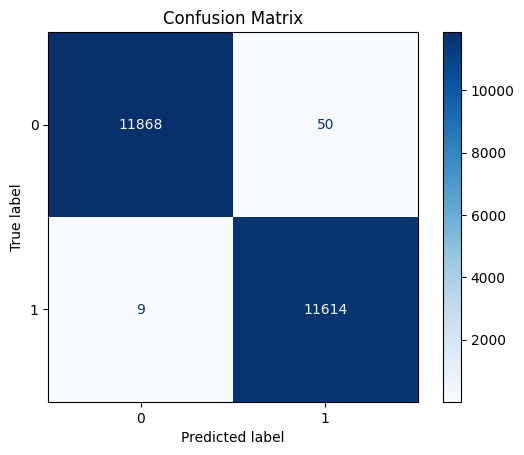

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#plots Confusion matrix
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, cmap='Blues', values_format='d')

plt.title("Confusion Matrix")
plt.show()

## The best Model is XGBoost Classifier with 99.7% accuracy and cost of 5000